# Output BAB 4.8 - Ketahanan Model pada Kondisi Data Ekstrem

Notebook ini menghasilkan studi kasus Sentinel-2 kosong/hampir kosong, topografi sulit/radar shadow candidate, badan air permanen, narasi keterbatasan, dan coverage checklist untuk subbab 4.8.

## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper toleran. Jika artefak belum tersedia, notebook membuat tabel status/warning dan tetap lanjut.


In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [2]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.8 Ketahanan Model pada Kondisi Data Ekstrem

Bagian ini menggunakan artefak 4.1.1 dan 4.2 untuk memilih wilayah/tile ekstrem secara terukur, lalu membuat visual pendukung untuk pembahasan keterbatasan model dan data.

saved table: outputs/bab4/tables/4_8_difficult_data_case_studies.csv (11 rows)


,region,tiles,valid_pixels,flood_pct_of_valid,water_river_pct_of_valid,s2_valid_pct_of_valid,optical_data_quality,slope_mean,slope_p98,hand_mean,condition_flag,recommended_use_in_discussion,status
7,Langsa,41,7395290,6.3725,10.0131,0.0000,kosong,0.067813,0.333014,0.144778,Sentinel-2 kosong/hampir kosong; water/river m...,yes,ok
4,Agam,278,54576695,1.9329,0.0000,0.0000,kosong,0.315526,0.983306,0.596339,Sentinel-2 kosong/hampir kosong; banjir sangat...,yes,ok
1,Aceh_Tamiang,465,82307919,4.2698,5.3545,0.0008,hampir kosong,0.229951,0.863305,0.528158,Sentinel-2 kosong/hampir kosong,yes,ok
8,Pasaman_Barat,522,115359798,1.1311,0.0000,0.0022,hampir kosong,0.217607,0.848587,0.508309,Sentinel-2 kosong/hampir kosong; banjir sangat...,yes,ok
3,Aceh_Utara,493,102158650,18.3842,12.5645,79.5878,baik,0.145603,0.578597,0.465163,water/river mask dominan,yes,ok
10,Pidie_Jaya,152,34130353,5.0772,3.2262,91.5386,baik,0.336579,0.804455,0.667681,topografi relatif curam,yes,ok
9,Pidie,572,110864777,5.8758,2.7297,95.8625,baik,0.332035,0.790920,0.682571,topografi relatif curam,yes,ok
2,Aceh_Timur,1063,206802875,5.6810,4.5989,53.8605,baik,0.235729,0.778596,0.550501,normal/usable,optional,ok
0,Aceh_Besar,518,106956513,4.6434,2.4376,80.5364,baik,0.299035,0.824756,0.604632,normal/usable,optional,ok
5,Banda_Aceh,16,2532433,6.0722,2.9938,83.8523,baik,0.045490,0.177945,0.063709,normal/usable,optional,ok


saved figure: outputs/bab4/figures/4_8_difficult_data_case_studies.png


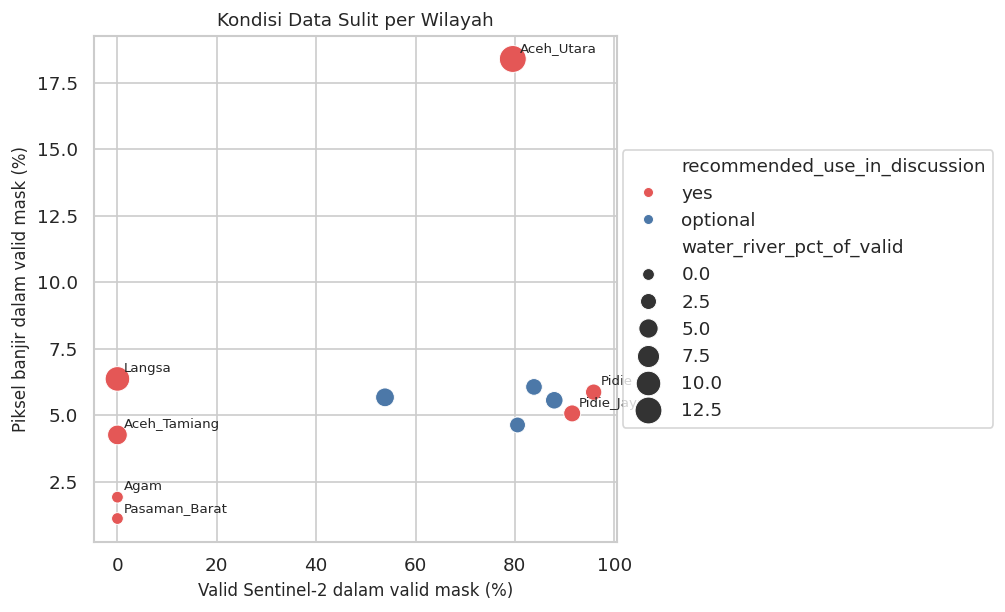

In [3]:
label_stats = pd.read_csv(TABLE_DIR / '4_2_label_mask_tile_stats.csv')
s2_stats = pd.read_csv(TABLE_DIR / '4_1_1_s2_valid_mask_by_region.csv')
dem_stats = pd.read_csv(TABLE_DIR / '4_1_1_demnas_slope_hand_stats.csv')

slope_stats = dem_stats[dem_stats['channel'].eq('slope_norm')][['region', 'mean', 'p98']].rename(columns={'mean': 'slope_mean', 'p98': 'slope_p98'})
hand_stats = dem_stats[dem_stats['channel'].eq('hand_norm')][['region', 'mean', 'p2']].rename(columns={'mean': 'hand_mean', 'p2': 'hand_p2'})
case_studies = (
    label_stats
    .merge(s2_stats[['region', 'optical_data_quality', 's2_valid_pct_within_feature_valid']], on='region', how='left')
    .merge(slope_stats, on='region', how='left')
    .merge(hand_stats, on='region', how='left')
)

def condition_flags(row):
    flags = []
    s2 = row.get('s2_valid_pct_of_valid', np.nan)
    water = row.get('water_river_pct_of_valid', np.nan)
    flood = row.get('flood_pct_of_valid', np.nan)
    slope = row.get('slope_mean', np.nan)
    if pd.notna(s2) and s2 < 1:
        flags.append('Sentinel-2 kosong/hampir kosong')
    elif pd.notna(s2) and s2 < 50:
        flags.append('Sentinel-2 valid terbatas')
    if pd.notna(water) and water > 10:
        flags.append('water/river mask dominan')
    if pd.notna(flood) and flood < 2:
        flags.append('banjir sangat minor')
    if pd.notna(slope) and slope > 0.30:
        flags.append('topografi relatif curam')
    return '; '.join(flags) if flags else 'normal/usable'

case_studies['condition_flag'] = case_studies.apply(condition_flags, axis=1)
case_studies['recommended_use_in_discussion'] = np.where(case_studies['condition_flag'].eq('normal/usable'), 'optional', 'yes')
case_studies = case_studies[[
    'region', 'tiles', 'valid_pixels', 'flood_pct_of_valid', 'water_river_pct_of_valid',
    's2_valid_pct_of_valid', 'optical_data_quality', 'slope_mean', 'slope_p98', 'hand_mean',
    'condition_flag', 'recommended_use_in_discussion', 'status'
]].sort_values(['recommended_use_in_discussion', 's2_valid_pct_of_valid', 'water_river_pct_of_valid'], ascending=[False, True, False])
save_table(case_studies, '4_8_difficult_data_case_studies.csv')

fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_df = case_studies.copy()
plot_df['water_river_pct_of_valid'] = plot_df['water_river_pct_of_valid'].fillna(0)
sns.scatterplot(
    data=plot_df,
    x='s2_valid_pct_of_valid',
    y='flood_pct_of_valid',
    size='water_river_pct_of_valid',
    hue='recommended_use_in_discussion',
    ax=ax,
    sizes=(50, 260),
    palette={'yes': '#E45756', 'optional': '#4C78A8'},
)
for _, row in plot_df.iterrows():
    if row['recommended_use_in_discussion'] == 'yes':
        ax.annotate(row['region'], (row['s2_valid_pct_of_valid'], row['flood_pct_of_valid']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Valid Sentinel-2 dalam valid mask (%)')
ax.set_ylabel('Piksel banjir dalam valid mask (%)')
ax.set_title('Kondisi Data Sulit per Wilayah')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), borderaxespad=0)
fig.tight_layout()
path = FIG_DIR / '4_8_difficult_data_case_studies.png'
fig.savefig(path, bbox_inches='tight', dpi=300)
print(f'saved figure: {path.relative_to(ROOT)}')
plt.show()


In [4]:
def tile_files(region: str):
    return sorted((DATASET / 'tiles' / '7ch' / 'by_region' / region).glob('*.npz'))


def load_tile(path: Path) -> dict:
    z = load_npz(path)
    return {
        'path': path,
        'x': np.asarray(z['x']),
        'y': np.asarray(z['y']).squeeze().astype('uint8'),
        'valid': np.asarray(z.get('valid_mask', np.ones((1, 512, 512)))).squeeze() > 0,
        'water': np.asarray(z.get('water_river_mask', np.zeros((1, 512, 512)))).squeeze() > 0,
        'feature_valid': np.asarray(z.get('feature_valid_mask', np.ones((1, 512, 512)))).squeeze() > 0,
        's2_valid': np.asarray(z.get('s2_valid_mask', np.zeros((1, 512, 512)))).squeeze() > 0,
    }


def tile_metrics(path: Path) -> dict:
    t = load_tile(path)
    valid = t['valid'] & t['feature_valid']
    valid_count = int(valid.sum())
    x = t['x']
    hsv_zero = ((np.abs(x[2]) + np.abs(x[3]) + np.abs(x[4])) < 1e-6) & valid
    vv_dark = (x[0] < np.nanpercentile(x[0][valid], 20)) & valid if valid_count else np.zeros_like(valid)
    return {
        'tile': path.name,
        'path': path,
        'region': path.parent.name,
        'valid_pixels': valid_count,
        'label_positive_pixels': int(((t['y'] > 0) & valid).sum()),
        'flood_pct_valid': pct(int(((t['y'] > 0) & valid).sum()), valid_count) if valid_count else 0,
        'water_pixels': int((t['water'] & valid).sum()),
        'water_pct_valid': pct(int((t['water'] & valid).sum()), valid_count) if valid_count else 0,
        's2_valid_pixels': int((t['s2_valid'] & valid).sum()),
        's2_valid_pct_valid': pct(int((t['s2_valid'] & valid).sum()), valid_count) if valid_count else 0,
        'hsv_zero_pct_valid': pct(int(hsv_zero.sum()), valid_count) if valid_count else 0,
        'slope_mean': float(np.nanmean(x[5][valid])) if valid_count else np.nan,
        'slope_p90': float(np.nanpercentile(x[5][valid], 90)) if valid_count else np.nan,
        'hand_mean': float(np.nanmean(x[6][valid])) if valid_count else np.nan,
        'dark_vv_pct_valid': pct(int(vv_dark.sum()), valid_count) if valid_count else 0,
    }


def select_tile(regions: list[str], scorer, min_valid: int = 50000) -> dict:
    rows = []
    for region in regions:
        for path in tile_files(region):
            try:
                rec = tile_metrics(path)
            except Exception:
                continue
            if rec['valid_pixels'] < min_valid:
                continue
            rec['score'] = scorer(rec)
            rows.append(rec)
    if not rows:
        raise RuntimeError(f'No tile found for {regions}')
    df = pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)
    return df.iloc[0].to_dict(), df.head(10)

hsv_choice, hsv_candidates = select_tile(
    ['Aceh_Tamiang', 'Agam', 'Langsa', 'Pasaman_Barat'],
    lambda r: r['hsv_zero_pct_valid'] * 4 + r['label_positive_pixels'] * 0.002 + r['valid_pixels'] * 0.00001,
)
topo_choice, topo_candidates = select_tile(
    ['Agam', 'Pidie', 'Pidie_Jaya', 'Aceh_Tamiang', 'Pasaman_Barat'],
    lambda r: r['slope_p90'] * 1000 + r['dark_vv_pct_valid'] * 3 + r['label_positive_pixels'] * 0.001,
)
water_choice, water_candidates = select_tile(
    ['Aceh_Utara', 'Langsa', 'Aceh_Tamiang', 'Aceh_Timur'],
    lambda r: r['water_pct_valid'] * 5 + r['label_positive_pixels'] * 0.002 + r['valid_pixels'] * 0.00001,
)

selection_rows = []
for case_name, choice in [('HSV kosong/hampir kosong', hsv_choice), ('Topografi sulit/radar shadow candidate', topo_choice), ('Badan air permanen', water_choice)]:
    row = {k: v for k, v in choice.items() if k != 'path'}
    row['case_name'] = case_name
    row['path'] = str(choice['path'].relative_to(ROOT))
    selection_rows.append(row)
selection = pd.DataFrame(selection_rows)
cols = ['case_name', 'region', 'tile', 'path', 'score', 'valid_pixels', 'label_positive_pixels', 'flood_pct_valid', 's2_valid_pct_valid', 'hsv_zero_pct_valid', 'water_pct_valid', 'slope_mean', 'slope_p90', 'hand_mean', 'dark_vv_pct_valid']
save_table(selection[cols], '4_8_extreme_tile_selection.csv')


saved table: outputs/bab4/tables/4_8_extreme_tile_selection.csv (3 rows)


,case_name,region,tile,path,score,valid_pixels,label_positive_pixels,flood_pct_valid,s2_valid_pct_valid,hsv_zero_pct_valid,water_pct_valid,slope_mean,slope_p90,hand_mean,dark_vv_pct_valid
0,HSV kosong/hampir kosong,Aceh_Tamiang,Aceh_Tamiang_r001024_c003840.npz,dataset/tiles/7ch/by_region/Aceh_Tamiang/Aceh_...,697.35744,262144,147368,56.2164,0.0000,100.0000,56.2164,0.055610,0.158841,0.523941,20.0001
1,Topografi sulit/radar shadow candidate,Aceh_Tamiang,Aceh_Tamiang_r006501_c002304.npz,dataset/tiles/7ch/by_region/Aceh_Tamiang/Aceh_...,1060.00060,217448,0,0.0000,0.0000,100.0000,0.0000,0.718676,1.000000,0.869123,20.0002
2,Badan air permanen,Aceh_Utara,Aceh_Utara_r001280_c005632.npz,dataset/tiles/7ch/by_region/Aceh_Utara/Aceh_Ut...,894.91494,262144,247132,94.2734,95.8847,4.1153,79.6059,0.027116,0.071777,0.443853,20.0001


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_8_extreme_tile_selection.csv')

saved figure: outputs/bab4/figures/4_8_hsv_zero_tile_panel.png


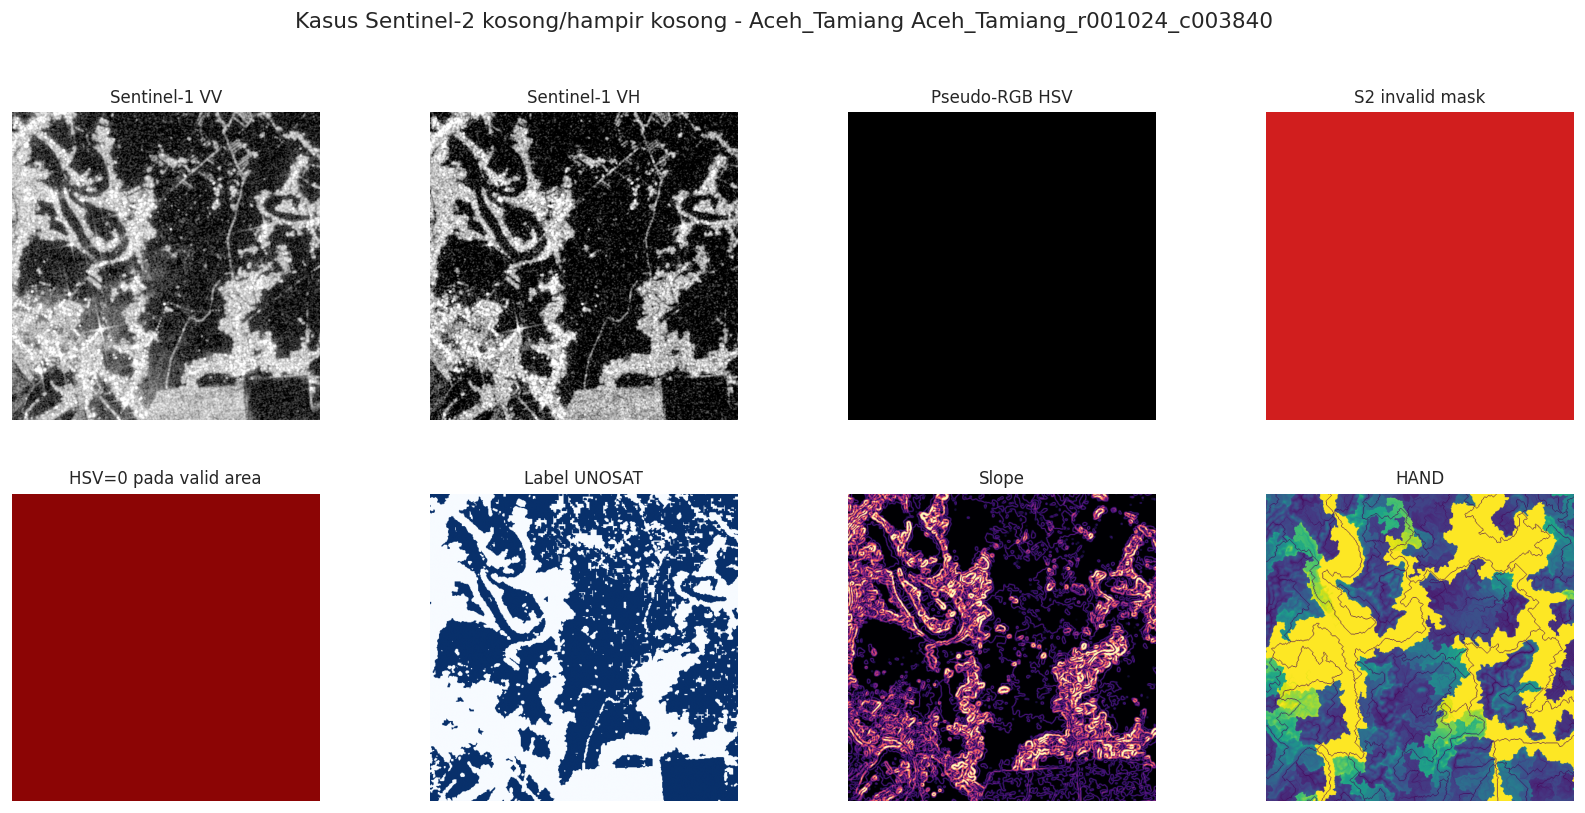

saved figure: outputs/bab4/figures/4_8_topography_radar_shadow_case.png


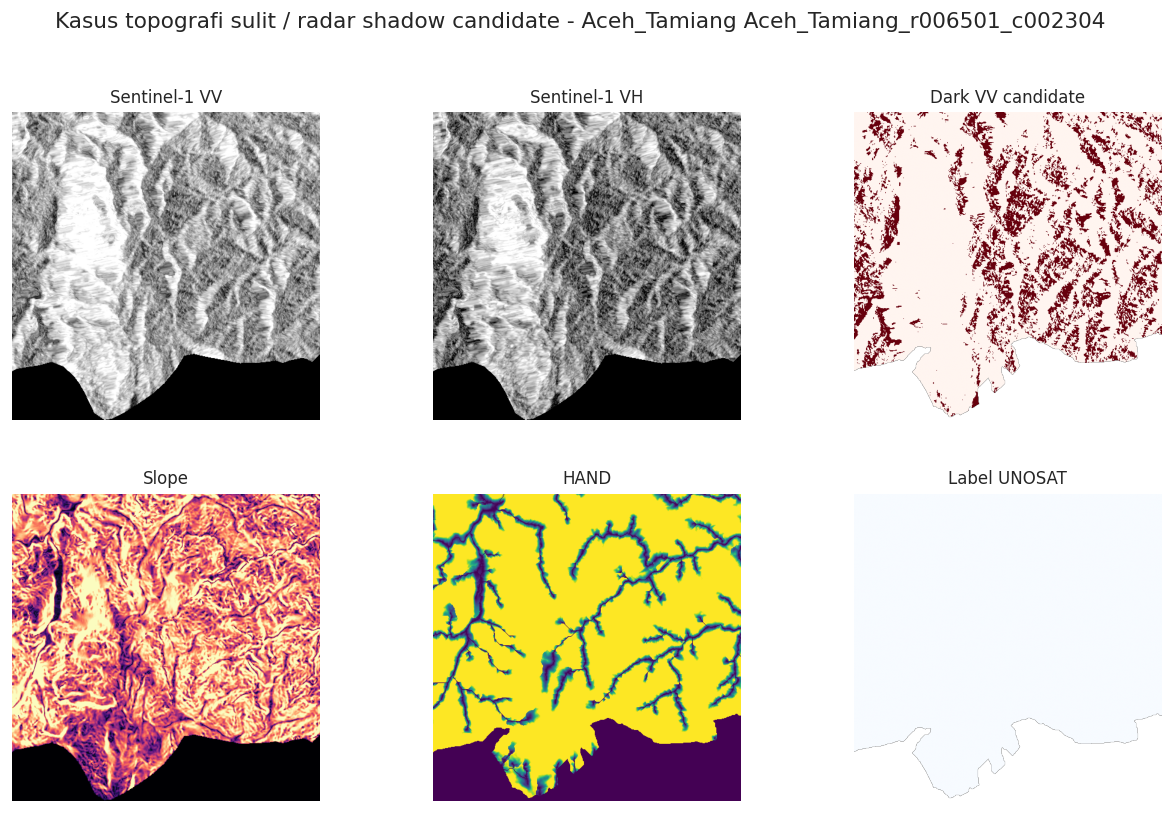

saved figure: outputs/bab4/figures/4_8_permanent_water_case.png


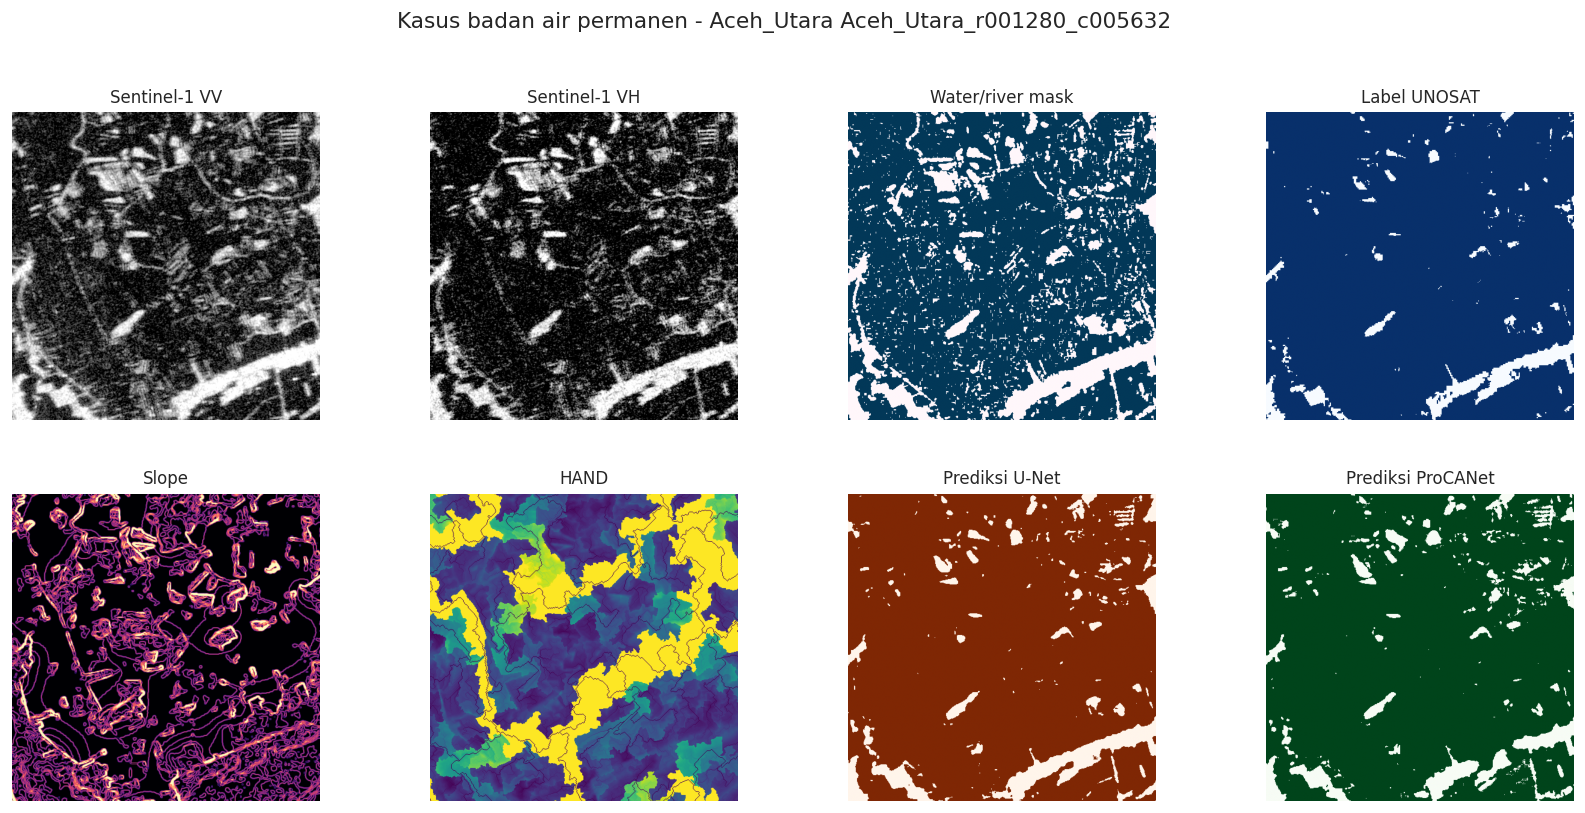

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_8_permanent_water_case.png')

In [5]:
def binary_rgb(true_mask: np.ndarray, valid_mask: np.ndarray, color: tuple[float, float, float], false_color: tuple[float, float, float] = (1, 1, 1)) -> np.ndarray:
    rgb = np.ones((*true_mask.shape, 3), dtype='float32')
    rgb[:] = false_color
    rgb[~valid_mask.astype(bool)] = (0.88, 0.88, 0.88)
    rgb[true_mask.astype(bool) & valid_mask.astype(bool)] = color
    return rgb

def show_panel(tile_path: Path, panels: list[tuple[str, np.ndarray, str | None]], title: str, name: str, ncols: int = 4):
    n = len(panels)
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.5 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, (panel_title, arr, cmap) in zip(axes, panels):
        if cmap:
            ax.imshow(arr, cmap=cmap)
        else:
            ax.imshow(arr)
        ax.set_title(panel_title, fontsize=10)
        ax.axis('off')
    for ax in axes[len(panels):]:
        ax.axis('off')
    fig.suptitle(title, fontsize=13, y=0.98)
    fig.subplots_adjust(top=0.86, bottom=0.04, left=0.03, right=0.98, hspace=0.24, wspace=0.08)
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches='tight', dpi=300)
    print(f'saved figure: {path.relative_to(ROOT)}')
    plt.show()
    return path

hsv_tile = load_tile(Path(hsv_choice['path']))
x = hsv_tile['x']
valid = hsv_tile['valid'] & hsv_tile['feature_valid']
hsv_zero_mask = ((np.abs(x[2]) + np.abs(x[3]) + np.abs(x[4])) < 1e-6) & valid
s2_invalid_mask = (~hsv_tile['s2_valid']) & valid
show_panel(
    Path(hsv_choice['path']),
    [
        ('Sentinel-1 VV', normalize_image(x[0]), 'gray'),
        ('Sentinel-1 VH', normalize_image(x[1]), 'gray'),
        ('Pseudo-RGB HSV', np.dstack([normalize_image(x[4]), normalize_image(x[3]), normalize_image(x[2])]), None),
        ('S2 invalid mask', binary_rgb(s2_invalid_mask, valid, (0.82, 0.12, 0.12)), None),
        ('HSV=0 pada valid area', binary_rgb(hsv_zero_mask, valid, (0.55, 0.02, 0.02)), None),
        ('Label UNOSAT', np.ma.masked_where(~valid, hsv_tile['y']), 'Blues'),
        ('Slope', normalize_image(x[5]), 'magma'),
        ('HAND', normalize_image(x[6]), 'viridis'),
    ],
    f"Kasus Sentinel-2 kosong/hampir kosong - {hsv_choice['region']} {hsv_choice['tile'].replace('.npz', '')}",
    '4_8_hsv_zero_tile_panel.png',
)

topo_tile = load_tile(Path(topo_choice['path']))
x = topo_tile['x']
valid = topo_tile['valid'] & topo_tile['feature_valid']
vv_dark = np.ma.masked_where(~valid, (x[0] < np.nanpercentile(x[0][valid], 20)).astype('uint8'))
show_panel(
    Path(topo_choice['path']),
    [
        ('Sentinel-1 VV', normalize_image(x[0]), 'gray'),
        ('Sentinel-1 VH', normalize_image(x[1]), 'gray'),
        ('Dark VV candidate', vv_dark, 'Reds'),
        ('Slope', normalize_image(x[5]), 'magma'),
        ('HAND', normalize_image(x[6]), 'viridis'),
        ('Label UNOSAT', np.ma.masked_where(~valid, topo_tile['y']), 'Blues'),
    ],
    f"Kasus topografi sulit / radar shadow candidate - {topo_choice['region']} {topo_choice['tile'].replace('.npz', '')}",
    '4_8_topography_radar_shadow_case.png',
    ncols=3,
)

water_tile = load_tile(Path(water_choice['path']))
x = water_tile['x']
valid = water_tile['valid'] & water_tile['feature_valid']
panels = [
    ('Sentinel-1 VV', normalize_image(x[0]), 'gray'),
    ('Sentinel-1 VH', normalize_image(x[1]), 'gray'),
    ('Water/river mask', np.ma.masked_where(~valid, water_tile['water']), 'PuBu'),
    ('Label UNOSAT', np.ma.masked_where(~valid, water_tile['y']), 'Blues'),
    ('Slope', normalize_image(x[5]), 'magma'),
    ('HAND', normalize_image(x[6]), 'viridis'),
]
# Add final predictions if this Aceh_Utara tile has matching inference outputs.
for model, label, cmap in [('unet', 'Prediksi U-Net', 'Oranges'), ('procanet', 'Prediksi ProCANet', 'Greens')]:
    pred_path = RUNS / 'final' / model / 'eval_test' / 'predictions' / water_choice['region'] / water_choice['tile']
    if pred_path.exists():
        pred = np.asarray(load_npz(pred_path)['prediction']).squeeze().astype('uint8')
        panels.append((label, np.ma.masked_where(~valid, pred), cmap))
show_panel(
    Path(water_choice['path']),
    panels,
    f"Kasus badan air permanen - {water_choice['region']} {water_choice['tile'].replace('.npz', '')}",
    '4_8_permanent_water_case.png',
    ncols=4,
)


In [6]:
lines = [
    '# Interpretasi Ketahanan Model pada Kondisi Data Ekstrem 4.8',
    '',
    f"Kasus Sentinel-2 kosong/hampir kosong ditunjukkan oleh tile `{hsv_choice['tile']}` di {hsv_choice['region']}. Pada tile ini persentase area valid dengan HSV nol mencapai {hsv_choice['hsv_zero_pct_valid']:.2f}% dan S2 valid hanya {hsv_choice['s2_valid_pct_valid']:.4f}% dari area valid. Kondisi ini menegaskan bahwa kanal optis tidak selalu menjadi sumber informasi yang andal; SAR, Slope, dan HAND tetap penting sebagai penyangga ketika Sentinel-2 tertutup awan, kosong, atau tidak valid.",
    '',
    f"Kasus topografi sulit/radar shadow candidate menggunakan tile `{topo_choice['tile']}` di {topo_choice['region']}. Tile ini dipilih karena slope p90 {topo_choice['slope_p90']:.4f} dan proporsi dark VV {topo_choice['dark_vv_pct_valid']:.2f}% pada area valid. Nilai dark VV tidak otomatis berarti banjir; pada daerah curam, bayangan radar atau perubahan geometri permukaan dapat membuat backscatter rendah. Di sini Slope dan HAND membantu membedakan area rendah yang lebih plausibel tergenang dari area gelap yang dipengaruhi topografi.",
    '',
    f"Kasus badan air permanen menggunakan tile `{water_choice['tile']}` di {water_choice['region']}, dengan water/river mask {water_choice['water_pct_valid']:.2f}% dari area valid. Mask ini penting karena badan air permanen dapat menyerupai banjir pada kanal SAR dan meningkatkan risiko false positive. Interpretasi prediksi perlu membedakan genangan banjir sementara dari sungai, tambak, atau badan air tetap.",
    '',
    'Label UNOSAT tetap digunakan sebagai proxy ground truth, tetapi bukan pengukuran sempurna. Perbedaan tanggal pengamatan, batas poligon, resolusi rasterisasi, dan kondisi tutupan awan dapat membuat sebagian area banjir tampak sebagai false negative atau false positive padahal sumber ketidakpastiannya berasal dari label. Karena itu, hasil visual dan metrik perlu dibaca sebagai evaluasi terhadap label UNOSAT, bukan kebenaran hidrologis mutlak.',
    '',
    'Generalisasi model juga masih terbatas oleh distribusi wilayah dan kejadian banjir yang tersedia. Spatial split membantu mengurangi kebocoran antar tile, tetapi belum otomatis menjamin performa di pulau, musim, sensor, atau kejadian banjir yang berbeda. Pembahasan 4.8 sebaiknya menekankan bahwa ketahanan model didukung oleh fusi SAR-optis-topografi, namun tetap dibatasi kualitas Sentinel-2, karakter topografi, badan air permanen, dan ketidakpastian label.',
]
path = NARRATIVE_DIR / '4_8_data_extreme_limitations_interpretation.md'
path.write_text('\n'.join(lines) + '\n')
print(f'saved narrative: {path.relative_to(ROOT)}')
print('\n'.join(lines))


saved narrative: outputs/bab4/narratives/4_8_data_extreme_limitations_interpretation.md
# Interpretasi Ketahanan Model pada Kondisi Data Ekstrem 4.8

Kasus Sentinel-2 kosong/hampir kosong ditunjukkan oleh tile `Aceh_Tamiang_r001024_c003840.npz` di Aceh_Tamiang. Pada tile ini persentase area valid dengan HSV nol mencapai 100.00% dan S2 valid hanya 0.0000% dari area valid. Kondisi ini menegaskan bahwa kanal optis tidak selalu menjadi sumber informasi yang andal; SAR, Slope, dan HAND tetap penting sebagai penyangga ketika Sentinel-2 tertutup awan, kosong, atau tidak valid.

Kasus topografi sulit/radar shadow candidate menggunakan tile `Aceh_Tamiang_r006501_c002304.npz` di Aceh_Tamiang. Tile ini dipilih karena slope p90 1.0000 dan proporsi dark VV 20.00% pada area valid. Nilai dark VV tidak otomatis berarti banjir; pada daerah curam, bayangan radar atau perubahan geometri permukaan dapat membuat backscatter rendah. Di sini Slope dan HAND membantu membedakan area rendah yang lebih plausibel

In [7]:
expected = [
    ('sangat_disarankan', 'Wilayah Sentinel-2 kosong/hampir kosong', TABLE_DIR / '4_8_difficult_data_case_studies.csv'),
    ('disarankan', 'Scatter kondisi data sulit per wilayah', FIG_DIR / '4_8_difficult_data_case_studies.png'),
    ('opsional', 'Contoh tile HSV=0', FIG_DIR / '4_8_hsv_zero_tile_panel.png'),
    ('opsional', 'Studi kasus topografi sulit/radar shadow', FIG_DIR / '4_8_topography_radar_shadow_case.png'),
    ('opsional', 'Studi kasus badan air permanen', FIG_DIR / '4_8_permanent_water_case.png'),
    ('wajib', 'Tabel seleksi tile ekstrem', TABLE_DIR / '4_8_extreme_tile_selection.csv'),
    ('narasi_wajib', 'Peran Slope/HAND', NARRATIVE_DIR / '4_8_data_extreme_limitations_interpretation.md'),
    ('narasi_wajib', 'Keterbatasan UNOSAT', NARRATIVE_DIR / '4_8_data_extreme_limitations_interpretation.md'),
    ('narasi_wajib', 'Keterbatasan generalisasi', NARRATIVE_DIR / '4_8_data_extreme_limitations_interpretation.md'),
]
coverage = pd.DataFrame([
    {
        'priority': priority,
        'todo_item': item,
        'artifact': str(path.relative_to(ROOT)),
        'exists': path.exists(),
        'size_bytes': path.stat().st_size if path.exists() else 0,
    }
    for priority, item, path in expected
])
save_table(coverage, '4_8_todo_coverage_checklist.csv')
missing = coverage[~coverage['exists']]
if missing.empty:
    print('All 4.8 checklist artifacts are available.')
else:
    display(missing)


saved table: outputs/bab4/tables/4_8_todo_coverage_checklist.csv (9 rows)


,priority,todo_item,artifact,exists,size_bytes
0,sangat_disarankan,Wilayah Sentinel-2 kosong/hampir kosong,outputs/bab4/tables/4_8_difficult_data_case_st...,True,1822
1,disarankan,Scatter kondisi data sulit per wilayah,outputs/bab4/figures/4_8_difficult_data_case_s...,True,158380
2,opsional,Contoh tile HSV=0,outputs/bab4/figures/4_8_hsv_zero_tile_panel.png,True,3604195
3,opsional,Studi kasus topografi sulit/radar shadow,outputs/bab4/figures/4_8_topography_radar_shad...,True,3425974
4,opsional,Studi kasus badan air permanen,outputs/bab4/figures/4_8_permanent_water_case.png,True,4397927
5,wajib,Tabel seleksi tile ekstrem,outputs/bab4/tables/4_8_extreme_tile_selection...,True,948
6,narasi_wajib,Peran Slope/HAND,outputs/bab4/narratives/4_8_data_extreme_limit...,True,2243
7,narasi_wajib,Keterbatasan UNOSAT,outputs/bab4/narratives/4_8_data_extreme_limit...,True,2243
8,narasi_wajib,Keterbatasan generalisasi,outputs/bab4/narratives/4_8_data_extreme_limit...,True,2243


All 4.8 checklist artifacts are available.
